FUNNEL ANALYSIS

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [4]:
df=pd.read_csv('/Users/niharika/Desktop/Project/PROJECT 2 Funnel Analysis/funnel_analysis_data.csv')

In [ ]:
df.head()

In [ ]:
df.info()

In [5]:
df['Timestamp']= pd.to_datetime(df['Timestamp'])
#df['Time']= pd.to_datetime(df['Time'])

In [ ]:
df.isnull().sum()

In [ ]:
df.columns

In [ ]:
df.describe()

In [ ]:
df.describe(include='object')

In [6]:
pd.set_option('Display.max_rows',None)

In [ ]:
df

DATA PREPAROCESSING

In [7]:
df['Event_Sequence']=df.groupby('Session_ID').cumcount()+1
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Event_Sequence
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes,1
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes,2
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes,3
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No,1
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No,2


In [8]:
#Extracting the Date and Time

df["Date"]=df["Timestamp"].dt.date
df["DayOfWeek"]=df["Timestamp"].dt.day_name()
df["Hour"]=df["Timestamp"].dt.hour
df["WeekNumnber"]=df["Timestamp"].dt.isocalendar().week

In [9]:
#Basic Analysis

print(f'Total Users {df['User_ID'].nunique()}')
print(f'Total Sessions {df['Session_ID'].nunique()}')
print(f'Data Range {df['Date'].min()} to {df['Date'].max()}')

Total Users 10000
Total Sessions 10000
Data Range 2025-10-01 to 2025-10-31


FUNNEL STAGE DEFINITION AND SESSION LEVEL AGGREGATION

In [52]:
df.head()
df.to_csv('Using.csv')

In [53]:
#Funnel Stages

funnels=['Browse', 'Add to Cart', 'Checkout', 'Purchase']

#Session level summary
Session_summary=df.groupby('Session_ID').agg({
    'User_ID':'first',
    'Timestamp':['min','max'],
    'Event':lambda x:list(x),
    'Device':'first',
    'Region':'first',
    'Channel':'first',
    'Product_Category':'first',
    'Revenue':'max',
    'Bounce_Flag':'first'
}).reset_index()

#Flatten Column names
Session_summary.columns=['Session_ID','User_ID','Session_Start','Session_End','Event_Sequence','Device',
                        'Region','Channel','Product_Category','Revenue','Bounce_Flag']

#Calculation of sessiion duration in minutes
Session_summary['Session_Duration_Min']=(
    Session_summary['Session_End'] - Session_summary['Session_Start']
).dt.total_seconds()/60

#Identifying the max funnel stage reached for each session
def get_max_funnel_stage(events):
    stage_values={stage: i for i, stage in enumerate(funnels)}
    max_stage_index=-1
    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]
        return funnels[max_stage_index] if max_stage_index != -1 else 'Browse'

Session_summary['Max_Funnel_Stage']= Session_summary['Event_Sequence'].apply(get_max_funnel_stage)

print('Session Summary Created:')
display(Session_summary.head())


Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2025-10-28 07:33:50,2025-10-28 07:40:50,"[Browse, Add to Cart, Checkout]",Desktop,West,Organic,Home,0.00,Yes,7.0,Browse
1,SES00002,USR00002,2025-10-19 09:15:10,2025-10-19 09:27:10,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Email,Electronics,448.18,No,12.0,Browse
2,SES00003,USR00003,2025-10-12 02:19:00,2025-10-12 02:29:00,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Google Ads,Beauty,1437.19,No,10.0,Browse
3,SES00004,USR00004,2025-10-05 17:55:48,2025-10-05 17:55:48,[Browse],Tablet,West,Social Media,Home,0.00,Yes,0.0,Browse
4,SES00005,USR00005,2025-10-19 12:35:49,2025-10-19 12:37:49,"[Browse, Add to Cart]",Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,Browse


In [10]:
# Funnel Stages2
funnels = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

# Session level summary
Session_summary = df.groupby('Session_ID').agg({
    'User_ID': 'first',
    'Timestamp': ['min','max'],
    'Event': lambda x: list(x),
    'Device': 'first',
    'Region': 'first',
    'Channel': 'first',
    'Product_Category': 'first',
    'Revenue': 'max',
    'Bounce_Flag': 'first'
}).reset_index()

# Flatten Column names
Session_summary.columns = [
    'Session_ID','User_ID','Session_Start','Session_End','Event_Sequence',
    'Device','Region','Channel','Product_Category','Revenue','Bounce_Flag'
]

# Calculation of session duration in minutes
Session_summary['Session_Duration_Min'] = (
    Session_summary['Session_End'] - Session_summary['Session_Start']
).dt.total_seconds() / 60


# Identifying the max funnel stage reached for each session
def get_max_funnel_stage(events):

    stage_values = {stage: i for i, stage in enumerate(funnels)}
    max_stage_index = -1

    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]

    if max_stage_index != -1:
        return funnels[max_stage_index]
    else:
        return 'Browse'


Session_summary['Max_Funnel_Stage'] = Session_summary['Event_Sequence'].apply(get_max_funnel_stage)

print('Session Summary Created:')
display(Session_summary.head())

Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2025-10-28 07:33:50,2025-10-28 07:40:50,"[Browse, Add to Cart, Checkout]",Desktop,West,Organic,Home,0.00,Yes,7.0,Checkout
1,SES00002,USR00002,2025-10-19 09:15:10,2025-10-19 09:27:10,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Email,Electronics,448.18,No,12.0,Purchase
2,SES00003,USR00003,2025-10-12 02:19:00,2025-10-12 02:29:00,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Google Ads,Beauty,1437.19,No,10.0,Purchase
3,SES00004,USR00004,2025-10-05 17:55:48,2025-10-05 17:55:48,[Browse],Tablet,West,Social Media,Home,0.00,Yes,0.0,Browse
4,SES00005,USR00005,2025-10-19 12:35:49,2025-10-19 12:37:49,"[Browse, Add to Cart]",Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,Add to Cart


OVERALL FUNNEL ANALYSIS

In [11]:
# Overall Funnel Matrix2
funnel_metrics = []

for i, stage in enumerate(funnels):
    if i == 0:
        count = len(Session_summary)
    else:
        count = len(Session_summary[Session_summary['Max_Funnel_Stage'].isin(funnels[i:])])

    funnel_metrics.append({
        'Stage': stage,
        'Sessions': count,
        'Stage_Order': i
    })

funnel_df = pd.DataFrame(funnel_metrics)

# Conversion rate
funnel_df['Conversion_Rate'] = (funnel_df['Sessions'] / funnel_df['Sessions'].iloc[0] * 100).round(2)

# Drop-off rate
funnel_df['Drop_Off_Rate'] = (1 - funnel_df['Sessions'] / funnel_df['Sessions'].shift(1)) * 100
funnel_df.loc[0, 'Drop_Off_Rate'] = 0
funnel_df['Drop_Off_Rate'] = funnel_df['Drop_Off_Rate'].round(2)

print("Overall Funnel Analysis:")
print(funnel_df.to_string(index=False))

# Revenue Analysis
revenue_stats = Session_summary[Session_summary['Max_Funnel_Stage'] == 'Purchase'].agg({
    'Revenue': ['sum', 'mean', 'count']
}).round(2)

print("\nRevenue Analysis:")
print(f"Total Revenue: ${revenue_stats.iloc[0,0]:,.2f}")
print(f"Average Order Value: ${revenue_stats.iloc[1,0]:,.2f}")
print(f"Total Orders: {int(revenue_stats.iloc[2,0]):,}")

Overall Funnel Analysis:
      Stage  Sessions  Stage_Order  Conversion_Rate  Drop_Off_Rate
     Browse     10000            0           100.00           0.00
Add to Cart      7059            1            70.59          29.41
   Checkout      3524            2            35.24          50.08
   Purchase      1080            3            10.80          69.35

Revenue Analysis:
Total Revenue: $1,176,405.78
Average Order Value: $1,089.26
Total Orders: 1,080


VISUALIZATION

In [13]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Funnel Visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Funnel Conversion Rates', 'Stage-to-Stage Drop-off',
                    'Revenue by Funnel Stage', 'Session Duration by Stage'),
    specs=[[{'secondary_y': False}, {'secondary_y': False}],
           [{'secondary_y': False}, {'secondary_y': False}]]
)

# Funnel conversion rates
fig.add_trace(
    go.Bar(
        x=funnel_df['Stage'],
        y=funnel_df['Sessions'],
        text=funnel_df['Sessions'],
        textposition='auto',
        name='Sessions',
        marker_color='lightblue'
    ),
    row=1, col=1
)

# Drop-off rates
fig.add_trace(
    go.Scatter(
        x=funnel_df['Stage'],
        y=funnel_df['Drop_Off_Rate'],
        mode='lines+markers+text',
        text=funnel_df['Drop_Off_Rate'],
        textposition='top center',
        name='Drop off Rate (%)',
        line=dict(color='red', width=3)
    ),
    row=1, col=2
)

# Revenue by stages
revenue_by_stage = Session_summary.groupby('Max_Funnel_Stage')['Revenue'].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=revenue_by_stage['Max_Funnel_Stage'],
        y=revenue_by_stage['Revenue'],
        text=[f'${x:,.0f}' for x in revenue_by_stage['Revenue']],
        textposition='auto',
        name='Revenue',
        marker_color='green'
    ),
    row=2, col=1
)

# Session duration by stage
duration_by_stage = Session_summary.groupby('Max_Funnel_Stage')['Session_Duration_Min'].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=duration_by_stage['Max_Funnel_Stage'],
        y=duration_by_stage['Session_Duration_Min'],
        text=duration_by_stage['Session_Duration_Min'].round(2),
        textposition='auto',
        name='Avg Session Duration (min)',
        marker_color='orange'
    ),
    row=2, col=2
)

fig.update_layout(
    height=800,
    title_text='Funnel Analysis Dashboard',
    showlegend=False
)

fig.show()

CHANNEL PERFORMANCE ANALYSIS

Channel Performance Analysis:


,Channel,Total_Sessions,Browse_Sessions,Browse_Rate,Add to Cart_Sessions,Add to Cart_Rate,Checkout_Sessions,Checkout_Rate,Purchase_Sessions,Purchase_Rate,Total Revenue,AOV,Conversion_Rate
0,Organic,2511,2511,100.0,1802,71.76,900,35.84,281,11.19,307448.35,1094.12,11.19
1,Social Media,2440,2440,100.0,1734,71.07,861,35.29,263,10.78,280071.63,1064.91,10.78
2,Email,2489,2489,100.0,1740,69.91,877,35.24,254,10.20,276116.54,1087.07,10.20
3,Google Ads,2560,2560,100.0,1783,69.65,886,34.61,282,11.02,312769.26,1109.11,11.02


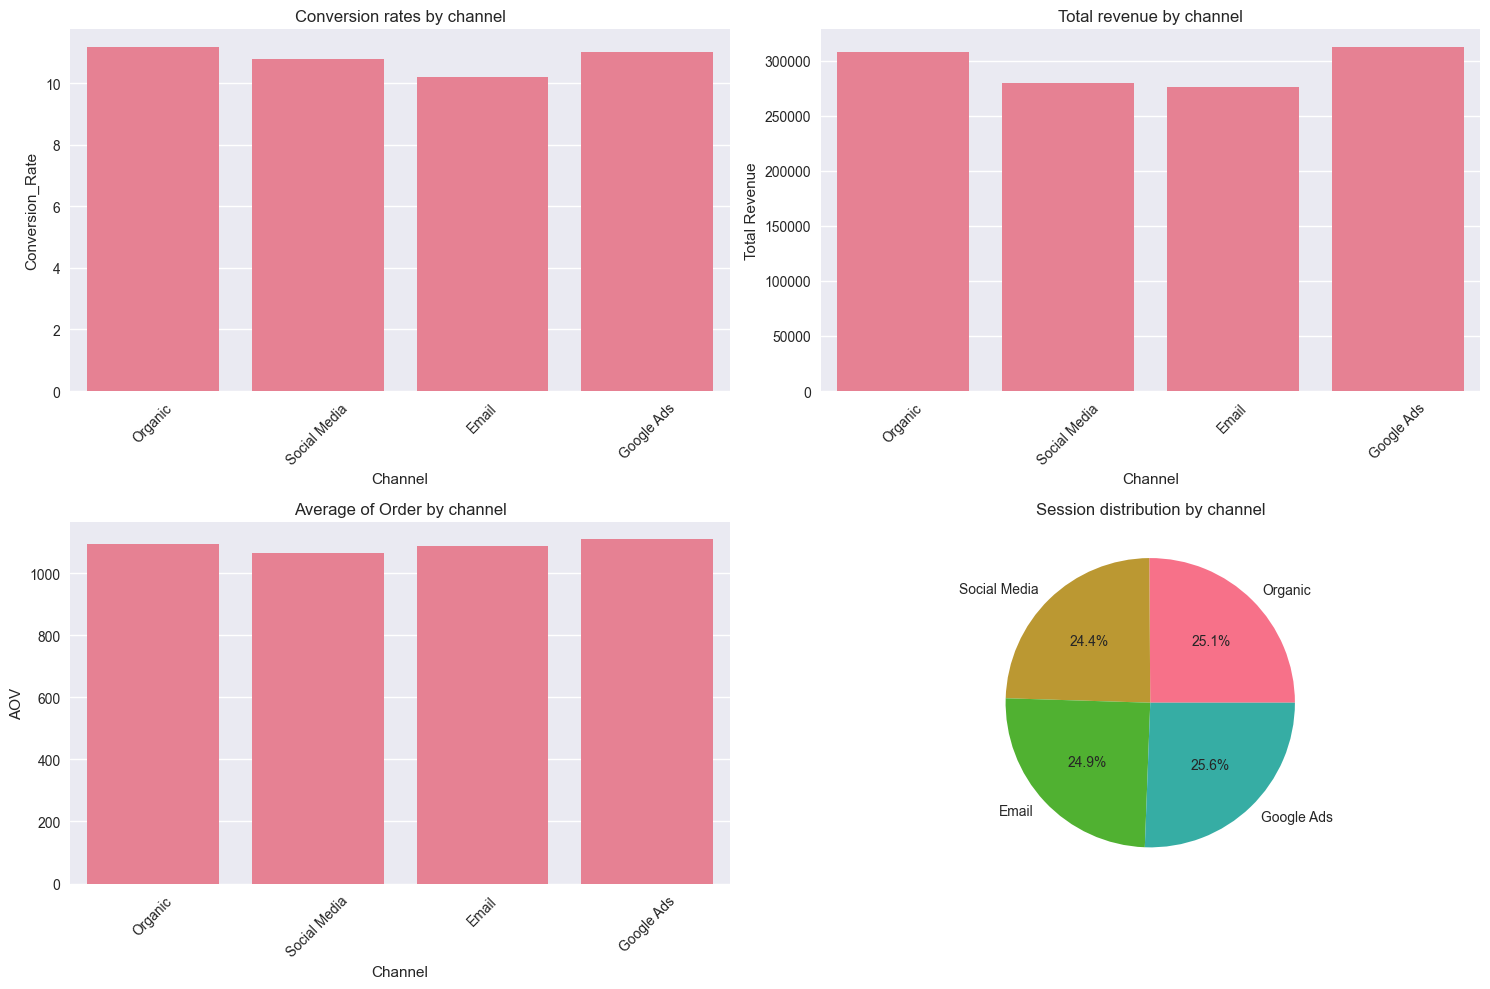

In [14]:
#Funnel Analysis by Channel
channel_funnel=[]

for channel in df['Channel'].unique():
    channel_sessions=Session_summary[Session_summary['Channel'] == channel]
    total_sessions=len(channel_sessions)

    if total_sessions > 0:
        channel_metrics = {'Channel': channel, 'Total_Sessions': total_sessions}

        for i, stage in enumerate(funnels):
            if i ==0:
                count=total_sessions
            else:
                count = len(channel_sessions[channel_sessions['Max_Funnel_Stage'].isin(funnels[i:])])
            
            channel_metrics[f'{stage}_Sessions']=count
            channel_metrics[f'{stage}_Rate']=(count/total_sessions * 100)

        #Revenue metrics
        purchase_sessions = channel_sessions[channel_sessions['Max_Funnel_Stage']=='Purchase']
        channel_metrics['Total Revenue']=purchase_sessions['Revenue'].sum()
        channel_metrics['AOV']=purchase_sessions['Revenue'].mean() if len(purchase_sessions)>0 else 0
        channel_metrics['Conversion_Rate']= (len(purchase_sessions)/ total_sessions * 100)

        channel_funnel.append(channel_metrics)
channel_df = pd.DataFrame(channel_funnel)

print("Channel Performance Analysis:")
display(channel_df.round(2))

#Visualize channel performance
fig,((ax1, ax2),(ax3,ax4))= plt.subplots(2,2,figsize=(15,10))

#Conversion rates by channel
sns.barplot(data=channel_df, x='Channel', y='Conversion_Rate', ax=ax1)
ax1.set_title('Conversion rates by channel')
ax1.tick_params(axis='x', rotation=45)

#Total revenue by channel
sns.barplot(data=channel_df, x='Channel', y='Total Revenue', ax=ax2)
ax2.set_title('Total revenue by channel')
ax2.tick_params(axis='x', rotation=45)

#AOV by channel
sns.barplot(data=channel_df, x='Channel', y='AOV', ax=ax3)
ax3.set_title('Average of Order by channel')
ax3.tick_params(axis='x', rotation=45)

#Session distribution by channel
channel_df['Session_Percentage']=(channel_df['Total_Sessions']/ channel_df['Total_Sessions'].sum() * 100)
ax4.pie(channel_df['Session_Percentage'], labels=channel_df['Channel'], autopct='%1.1f%%')
ax4.set_title('Session distribution by channel')

plt.tight_layout()
plt.show()

In [16]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Event_Sequence,Date,DayOfWeek,Hour,WeekNumnber
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes,1,2025-10-28,Tuesday,7,44
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes,2,2025-10-28,Tuesday,7,44
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes,3,2025-10-28,Tuesday,7,44
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No,1,2025-10-19,Sunday,9,42
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No,2,2025-10-19,Sunday,9,42


REGIONAL ANALYSIS

Regional Performance:


,Total_Sessions,Total Revenue,Session_Duration_Min,Converted_Sessions,Coneversion_Rate,AOV
Region,,,,,,
East,2514,301767.14,4.146778,280,11.14,1077.739786
North,2504,288027.95,3.998003,261,10.42,1103.555364
South,2506,311018.57,4.102155,282,11.25,1102.902730
West,2476,275592.12,4.080775,257,10.38,1072.342879


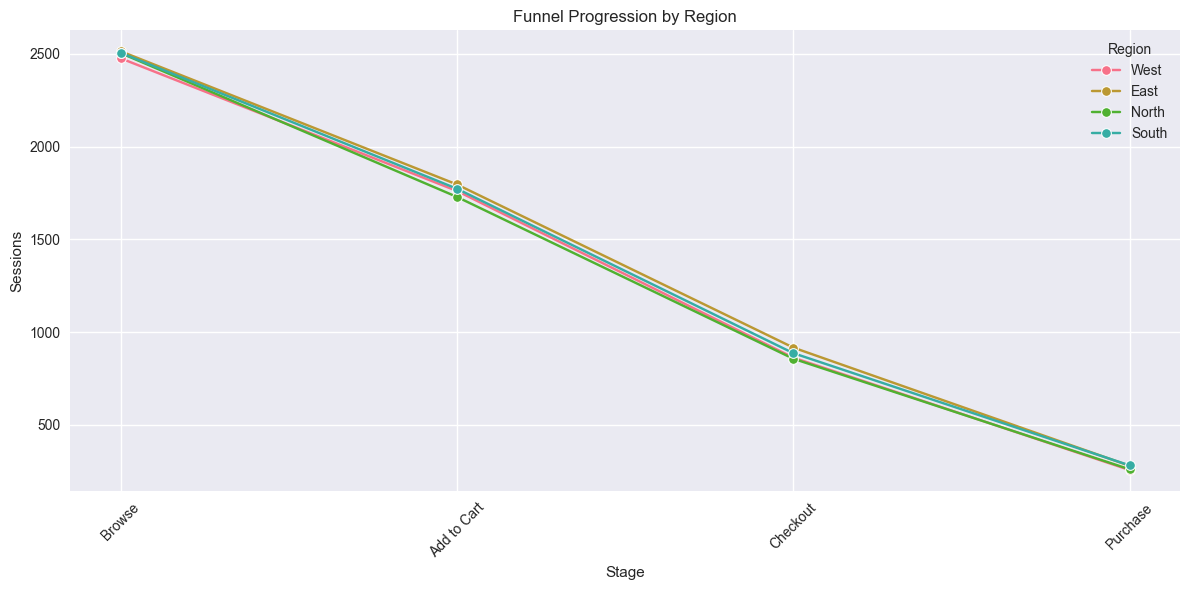

In [17]:
#Regional performance analysis
regional_analysis = Session_summary.groupby('Region').agg({
    'Session_ID': 'count',
    'Revenue':'sum',
    'Session_Duration_Min': 'mean'
}).rename(columns={'Session_ID': 'Total_Sessions', 'Revenue':'Total Revenue'})

#Add conersion rate by region
regional_conversion=Session_summary[Session_summary['Max_Funnel_Stage']=='Purchase'].groupby('Region').size()
regional_analysis['Converted_Sessions']=regional_conversion
regional_analysis['Coneversion_Rate']=(regional_analysis['Converted_Sessions']/ regional_analysis['Total_Sessions'] * 100).round(2)
regional_analysis['AOV']=(regional_analysis['Total Revenue']/ regional_analysis['Converted_Sessions'].round(2))

print('Regional Performance:')
display(regional_analysis)

#Reginal funnel visualization
regional_funnel_data = []
for region in df['Region'].unique():
    region_sessions=Session_summary[Session_summary['Region'] == region]
    for stage in funnels:
        if stage == 'Browse':
            count = len(region_sessions)
        else:
            count= len(region_sessions[region_sessions['Max_Funnel_Stage'].isin(funnels[funnels.index(stage):])])
        regional_funnel_data.append({'Region': region, 'Stage': stage, 'Sessions': count})
regional_funnel_df=pd.DataFrame(regional_funnel_data)

plt.figure(figsize=(12,6))
sns.lineplot(data=regional_funnel_df, x='Stage', y='Sessions', hue='Region', marker='o')
plt.title('Funnel Progression by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DEVICE AND PRODUCT CATEGORY ANALYSIS

Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate,AOV
Device,,,,,,
Desktop,3331,399395.43,4.095167,372,11.17,1073.64
Mobile,3345,405451.84,4.061584,363,10.85,1116.95
Tablet,3324,371558.51,4.089350,345,10.38,1076.98


Product Category Performance:


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV,Revenue_per_Session
Product_Category,,,,,,
Beauty,1978,241834.97,226,11.43,1070.07,122.26
Electronics,2046,226451.63,208,10.17,1088.71,110.68
Fashion,2035,237261.50,220,10.81,1078.46,116.59
Home,1941,232534.83,211,10.87,1102.06,119.80
Sports,2000,238322.85,215,10.75,1108.48,119.16


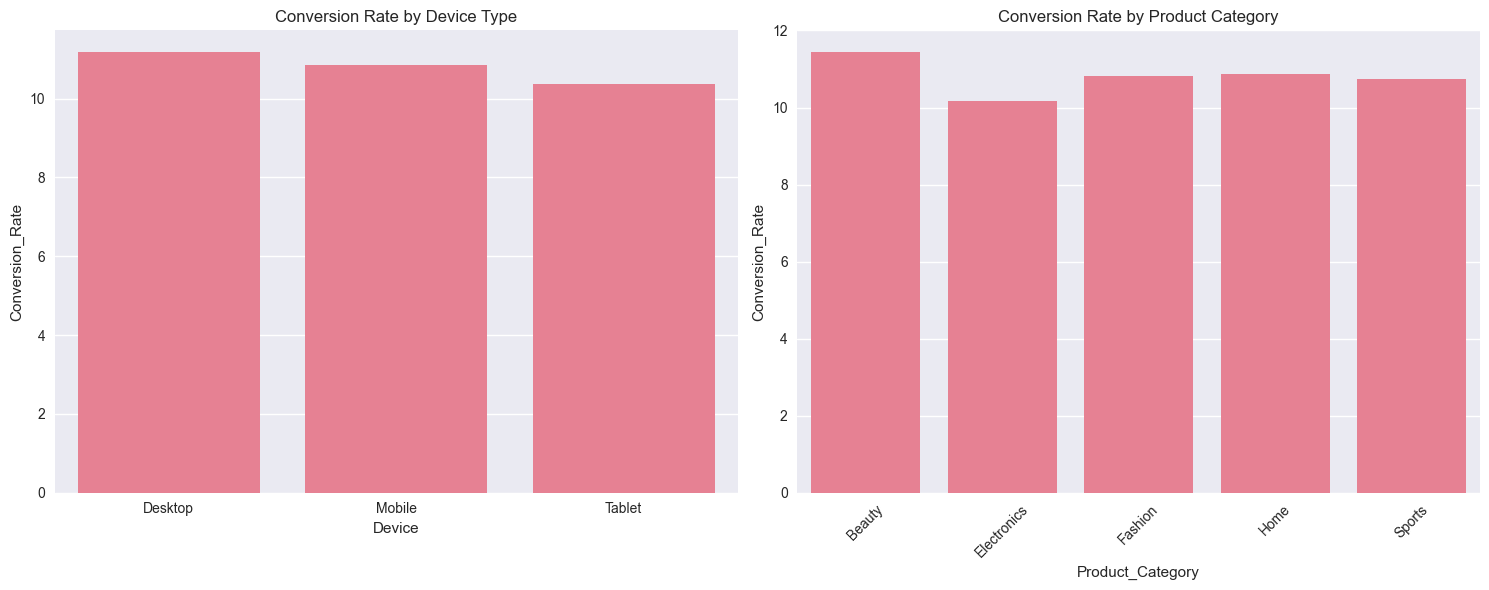

In [20]:
#Device performance
device_analysis=Session_summary.groupby('Device').agg({
    'Session_ID': 'count',
    'Revenue':'sum',
    'Session_Duration_Min': 'mean',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID':'Total_Sessions', 'Max_Funnel_Stage':'Purchases'})

device_analysis['Conversion_Rate']=(device_analysis['Purchases']/device_analysis['Total_Sessions'] * 100).round(2)
device_analysis['AOV']=(device_analysis['Revenue']/device_analysis['Purchases']).round(2)

print('Device Performance:')
display(device_analysis)

#Product Category Analysis
product_analysis=Session_summary.groupby('Product_Category').agg({
    'Session_ID': 'count',
    'Revenue':'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID':'Total_Sessions', 'Max_Funnel_Stage':'Purchases'}) 

product_analysis['Conversion_Rate']=(product_analysis['Purchases']/product_analysis['Total_Sessions'] * 100).round(2)
product_analysis['AOV']=(product_analysis['Revenue']/product_analysis['Purchases']).round(2)
product_analysis['Revenue_per_Session']=(product_analysis['Revenue']/product_analysis['Total_Sessions']).round(2)

print('Product Category Performance:')
display(product_analysis)

#Combined Visualization
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

#Device performance
sns.barplot(data=device_analysis.reset_index(), x='Device', y='Conversion_Rate', ax=ax1)
ax1.set_title('Conversion Rate by Device Type')

#Product Category Performance
sns.barplot(data=product_analysis.reset_index(), x='Product_Category', y='Conversion_Rate', ax=ax2)
ax2.set_title('Conversion Rate by Product Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

TIME BASED ANALYSIS

Daily Performance Trends:


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate
Date,,,,,
2025-10-22,300,300,33633.64,31,10.33
2025-10-23,347,347,50983.83,47,13.54
2025-10-24,315,315,39543.10,38,12.06
2025-10-25,364,364,50965.19,42,11.54
2025-10-26,355,355,42548.29,38,10.70
2025-10-27,310,310,41315.66,42,13.55
2025-10-28,347,347,39963.77,31,8.93
2025-10-29,336,336,29960.83,28,8.33
2025-10-30,331,331,35412.95,34,10.27


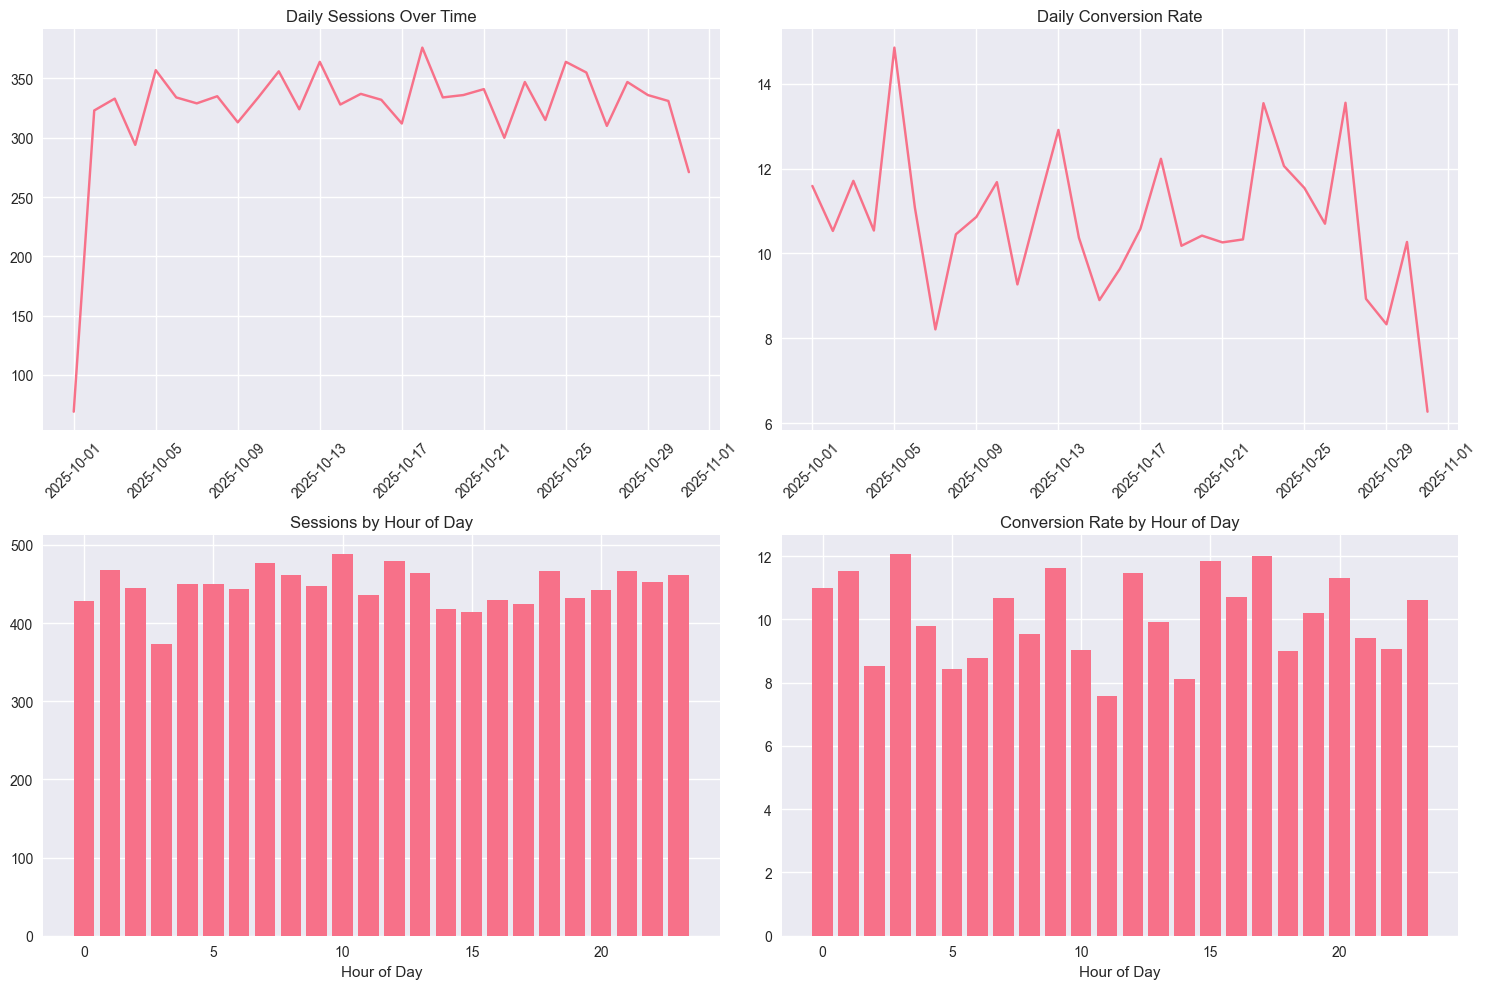

In [38]:
# Daily Trends

daily_metrics = df.groupby('Date').agg({
    'Session_ID': 'nunique',
    'User_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Daily_Sessions', 'User_ID': 'Daily_Users'})

daily_conversions = Session_summary[Session_summary['Max_Funnel_Stage'] == 'Purchase'].groupby(
    Session_summary['Session_Start'].dt.date
).size()

daily_metrics['Daily_Conversions'] = daily_conversions
daily_metrics['Daily_Conversion_Rate'] = (daily_metrics['Daily_Conversions'] / daily_metrics['Daily_Sessions'] * 100).round(2)

print('Daily Performance Trends:')
display(daily_metrics.tail(10))


# Hourly Patterns
hourly_sessions = df.groupby('Hour').agg({
    'Session_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Hourly_Sessions'})


hourly_conversions = Session_summary[Session_summary['Max_Funnel_Stage'] == 'Purchase'].copy()
hourly_conversions['Hour'] = hourly_conversions['Session_Start'].dt.hour

hourly_conversions_counts = hourly_conversions.groupby('Hour').size()

hourly_sessions['Hourly_Conversions'] = hourly_conversions_counts

hourly_sessions['Hourly_Conversion_Rate'] = (
    hourly_sessions['Hourly_Conversions'] / hourly_sessions['Hourly_Sessions'] * 100
).round(2)


# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Daily Sessions
ax1.plot(daily_metrics.index, daily_metrics['Daily_Sessions'])
ax1.set_title('Daily Sessions Over Time')
ax1.tick_params(axis='x', rotation=45)

# Daily Conversion Rate
ax2.plot(daily_metrics.index, daily_metrics['Daily_Conversion_Rate'])
ax2.set_title('Daily Conversion Rate')
ax2.tick_params(axis='x', rotation=45)

# Hourly Session Pattern
ax3.bar(hourly_sessions.index, hourly_sessions['Hourly_Sessions'])
ax3.set_title('Sessions by Hour of Day')
ax3.set_xlabel('Hour of Day')

#Hourly Conversion Rate
ax4.bar(hourly_sessions.index, hourly_sessions['Hourly_Conversion_Rate'])
ax4.set_title('Conversion Rate by Hour of Day')
ax4.set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

ADVANCED FUNNEL METRICS and KPIs

In [24]:
#Calculate advanced metrics
print('Key Performance Indicatorrs')
print('-'*35)

#Overall KPIs
total_sessions=len(Session_summary)
Total_Revenue=Session_summary['Revenue'].sum()
total_orders=len(Session_summary[Session_summary['Max_Funnel_Stage'] == 'Purchase'])
overall_conversion_rate=(total_orders/total_sessions *100)

print(f'\nOverall Conversion Rate: {overall_conversion_rate:.2f}%')
print(f'Total Revenue: {Total_Revenue:.2f}')
print(f'Average Order Value : ${(Total_Revenue/total_orders):.2f}')
print(f'Total Sessions: {total_sessions:,}')
print(f'Total Orders: {total_orders:,}')

#Funnel Efficiency Metrics
browse_to_cart=(funnel_df.iloc[1]['Sessions']/funnel_df.iloc[0]['Sessions']*100)
cart_to_checkout=(funnel_df.iloc[2]['Sessions']/funnel_df.iloc[1]['Sessions']*100)
checkout_to_puchase=(funnel_df.iloc[3]['Sessions']/funnel_df.iloc[2]['Sessions']*100)

print(f'\nStage to stage concersion rates:')
print(f'Browse -> Add to Cart: {browse_to_cart:.2f}%')
print(f'Add to Cart -> Checkout: {cart_to_checkout:.2f}%')
print(f'Checkout -> : {checkout_to_puchase:.2f}%')

#Revenue per session at each stage
revenue_per_browse=Total_Revenue/funnel_df.iloc[0]['Sessions']
revenue_per_cart=Total_Revenue/funnel_df.iloc[1]['Sessions']
revenue_per_checkout=Total_Revenue/funnel_df.iloc[2]['Sessions']

print(f'\nRevenue per Sessions by Stage:')
print(f'Pre Browse Sessions: ${revenue_per_browse:.2f}')
print(f'Per Cart Sessions ${revenue_per_cart:.2f}')
print(f'Per Checkout Sessions: ${revenue_per_checkout:.2f}')

#Bounce rate analysis
bounce_sessions=Session_summary[Session_summary['Bounce_Flag'] == 'Yes']
bounce_rate=(len(bounce_sessions)/total_sessions*100)
print(f'Bounce Rate: {bounce_rate:.2f}%')

#Session duration analysis
avg_session_duration=Session_summary['Session_Duration_Min'].mean()
print(f'\nAverage Session Duration: {avg_session_duration:.2f} minutes')

Key Performance Indicatorrs
-----------------------------------

Overall Conversion Rate: 10.80%
Total Revenue: 1176405.78
Average Order Value : $1089.26
Total Sessions: 10,000
Total Orders: 1,080

Stage to stage concersion rates:
Browse -> Add to Cart: 70.59%
Add to Cart -> Checkout: 49.92%
Checkout -> : 30.65%

Revenue per Sessions by Stage:
Pre Browse Sessions: $117.64
Per Cart Sessions $166.65
Per Checkout Sessions: $333.83
Bounce Rate: 89.20%

Average Session Duration: 4.08 minutes


STRATEGIC RECOMMENDATIONS

In [30]:
# Regional Analysis
regional_sessions = Session_summary.groupby('Region').size()

regional_purchases = Session_summary[
    Session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby('Region').size()

regional_revenue = Session_summary.groupby('Region')['Revenue'].sum()

regional_analysis = pd.DataFrame({
    'Sessions': regional_sessions,
    'Purchases': regional_purchases,
    'Revenue': regional_revenue
}).fillna(0)

regional_analysis['Conversion_Rate'] = (
    regional_analysis['Purchases'] / regional_analysis['Sessions'] * 100
).round(2)

In [33]:
product_sessions = Session_summary.groupby('Product_Category').size()

product_purchases = Session_summary[
    Session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby('Product_Category').size()

product_revenue = Session_summary.groupby('Product_Category')['Revenue'].sum()

product_analysis = pd.DataFrame({
    'Sessions': product_sessions,
    'Purchases': product_purchases,
    'Revenue': product_revenue
}).fillna(0)

product_analysis['Conversion_Rate'] = (
    product_analysis['Purchases'] / product_analysis['Sessions'] * 100
).round(2)

product_analysis['AOV'] = (
    product_analysis['Revenue'] / product_analysis['Purchases']
).fillna(0)

In [34]:
print("Strategic Recommendations")
print("-"*50)

# Ensure Conversion Rate exists in regional_analysis
if 'Conversion_Rate' not in regional_analysis.columns:
    regional_analysis['Conversion_Rate'] = (
        regional_analysis['Purchases'] / regional_analysis['Sessions'] * 100
    ).round(2)

# Ensure Conversion Rate exists in product_analysis
if 'Conversion_Rate' not in product_analysis.columns:
    product_analysis['Conversion_Rate'] = (
        product_analysis['Purchases'] / product_analysis['Sessions'] * 100
    ).round(2)

# Biggest Funnel Drop-off
max_dropoff_stage = funnel_df.loc[funnel_df['Drop_Off_Rate'].idxmax()]
print(f"Biggest Drop-Off: {max_dropoff_stage['Stage']} stage with {max_dropoff_stage['Drop_Off_Rate']}% drop-off")

# Best Channel
best_channel = channel_df.loc[channel_df['Conversion_Rate'].idxmax()]
print(f"Best Performing Channel: {best_channel['Channel']} with {best_channel['Conversion_Rate']}% conversion")

# Best Region
best_region = regional_analysis.loc[regional_analysis['Conversion_Rate'].idxmax()]
print(f"Best Performing Region: {best_region.name} with {best_region['Conversion_Rate']}% conversion")

# Best Product Category
best_category = product_analysis.loc[product_analysis['Conversion_Rate'].idxmax()]
print(f"Best Performing Category: {best_category.name} with {best_category['Conversion_Rate']}% conversion")

print("\nRecommended Actions")
print(f"1. Address {max_dropoff_stage['Stage']} stage drop-off through UX improvements")
print(f"2. Allocate more budget to {best_channel['Channel']} channel")
print(f"3. Replicate {best_region.name} region strategies in underperforming regions")
print(f"4. Promote {best_category.name} category to improve overall conversions")
print(f"5. Focus on cart abandonment recovery for {funnel_df.iloc[2]['Drop_Off_Rate']}% of users")

# Revenue Opportunity
cart_abandonment_opportunity = funnel_df.iloc[2]['Sessions'] * product_analysis['AOV'].mean()

print("\nRevenue Opportunity")
print(f"Cart abandonment recovery: ${cart_abandonment_opportunity:,.2f} potential revenue")

Strategic Recommendations
--------------------------------------------------
Biggest Drop-Off: Purchase stage with 69.35% drop-off
Best Performing Channel: Organic with 11.190760653126244% conversion
Best Performing Region: South with 11.25% conversion
Best Performing Category: Beauty with 11.43% conversion

Recommended Actions
1. Address Purchase stage drop-off through UX improvements
2. Allocate more budget to Organic channel
3. Replicate South region strategies in underperforming regions
4. Promote Beauty category to improve overall conversions
5. Focus on cart abandonment recovery for 50.08% of users

Revenue Opportunity
Cart abandonment recovery: $3,839,592.91 potential revenue


EXPORT RESULTS

In [35]:
report_data = {
    'Overall_Funnel': funnel_df,
    'Channel_Performance': channel_df,
    'Regional_Analysis': regional_analysis,
    'Device_Performance': device_analysis,
    'Product_Performance': product_analysis,
    'Daily_Trends': daily_metrics,
    'Hourly_Patterns': hourly_sessions
}

# Export to Excel
with pd.ExcelWriter('Funnel_Analysis_Report.xlsx') as writer:
    for sheet_name, data in report_data.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)

print("Analysis complete. Report exported to Excel")

Analysis complete. Report exported to Excel
